Portobello Tech is an app innovator who has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level. 

Data from prior evaluations shows the employees’ satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company.  

The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time. 

As the ML Developer assigned to the HR Department, you have been asked to create ML programs to: 

- Perform data quality checks by checking for missing values, if any. 
- Understand what factors contributed most to employee turnover at EDA. 
- Perform clustering of employees who left based on their satisfaction and evaluation. 
- Handle the left Class Imbalance using the SMOTE technique. 
- Perform k-fold cross-validation model training and evaluate performance.  
- Identify the best model and justify the evaluation metrics used.  
- Suggest various retention strategies for targeted employees. 

In [2]:
# DATA QUALITY CHECK AND BASIC PREPROCESSING
# Check for missing values, duplicates, data types
import numpy as np
import pandas as pd

data = pd.read_csv("HR_comma_sep.csv")

# shape has () since it is an attribute, meaning we are just accessing stored info, whereas head() exucutes the head method
print(data.head())
print(data.shape) # Gives us number of rows and columns
print(data.info())

print(data.isnull().sum()) # isnull() creates a true false table, sum() adds all the true values

# In this case we have no nulls but if I did here are some optionss for me
# data.dropna(), this removes entire rows that contain NAs, used only when a few are missing
# df['age'] = df["age"].fillna(df['age'].mean()), this we can replace our nulls with the average value of the column
# We can also do median by replacing mean() with median()


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     low  
4 

In [3]:
# Here we had some duplicates so we dropped them
print(data.duplicated().sum())
data = data.drop_duplicates()
print(data.duplicated().sum())


3008
0


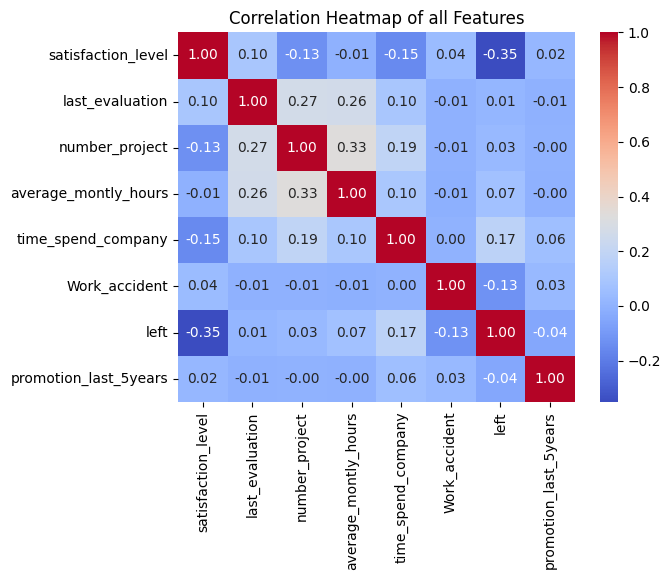

In [4]:
# EDA, Exploratory Data Analysis
# THis is done so we can understand the data like patterns, coorelations, feature importance etc
import matplotlib.pyplot as plt
import seaborn as sns

numericalData = data.drop(['sales','salary'], axis=1) # Remember axis=1 drops columns

# corr() calculates the correaltion matrix, annot writes number in the box, fmt = .2f means 2 decimals and float
sns.heatmap(numericalData.corr(), annot=True, cmap='coolwarm', fmt=".2f") 
plt.title("Correlation Heatmap of all Features")
plt.show()


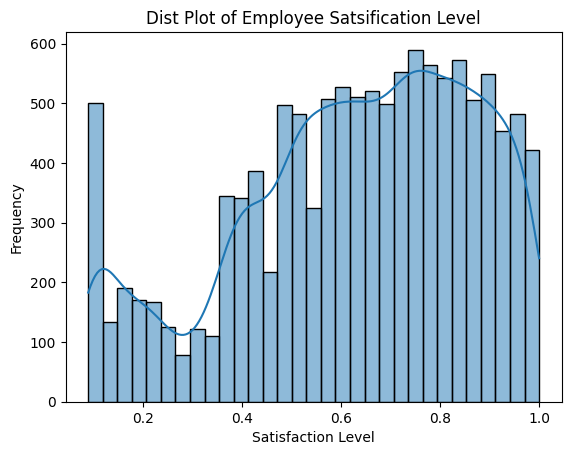

In [5]:
# Histogram shows how frequenly values appear in a column
sns.histplot(data['satisfaction_level'],kde=True) # kde adds smooth curve line over the bars
plt.title("Dist Plot of Employee Satsification Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Frequency")
plt.show()

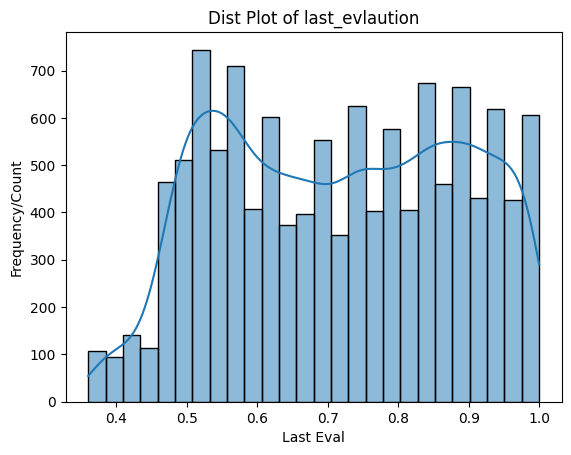

In [6]:
sns.histplot(data['last_evaluation'], kde=True)
plt.title('Dist Plot of last_evlaution')
plt.xlabel("Last Eval")
plt.ylabel('Frequency/Count')
plt.show()

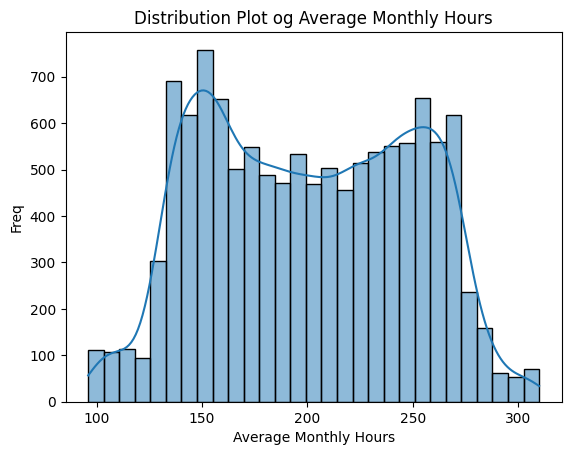

In [7]:
sns.histplot(data['average_montly_hours'], kde=True)
plt.title("Distribution Plot og Average Monthly Hours")
plt.xlabel('Average Monthly Hours')
plt.ylabel('Freq')
plt.show()


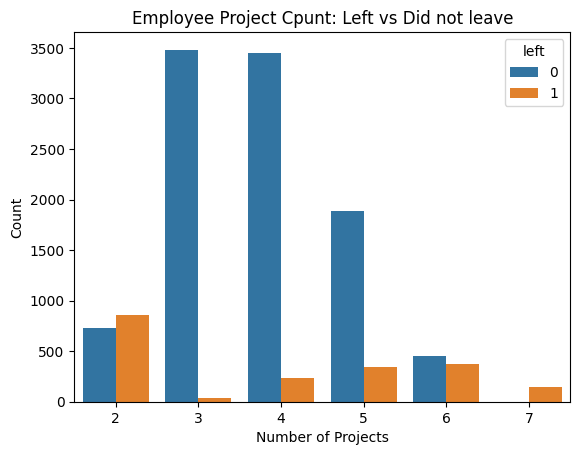

In [8]:
# Bar plot is used to compare values between different categories
sns.countplot(x='number_project', hue='left', data=data)
plt.title("Employee Project Cpunt: Left vs Did not leave")
plt.xlabel("Number of Projects")
plt.ylabel("Count")
plt.show()

      satisfaction_level  last_evaluation  Cluster
0                   0.38             0.53        0
1                   0.80             0.86        1
2                   0.11             0.88        2
3                   0.72             0.87        1
4                   0.37             0.52        0
...                  ...              ...      ...
1995                0.37             0.57        0
1996                0.11             0.92        2
1997                0.41             0.53        0
1998                0.84             0.96        1
1999                0.40             0.51        0

[1991 rows x 3 columns]
Cluster
0    902
1    555
2    534
Name: count, dtype: int64
         satisfaction_level  last_evaluation
Cluster                                     
0                  0.410133         0.517195
1                  0.805874         0.912577
2                  0.111199         0.869064


/var/folders/km/kgtp2fsd5w9c6td4r6ss58th0000gn/T/ipykernel_98173/3962529549.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['Cluster'] = model.fit_predict(selected_data) # THis returns an arrya of clusters labels which we make a column


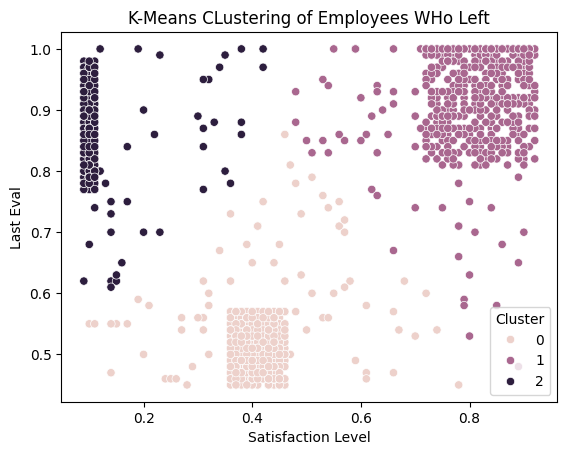

In [9]:
# K-Clustering on employees who left
# Here we are not predicting, we are filtering out the people who left and trying to cluster and find patterns within that group
# Keep in mind that we can calculate the WCSS for diff numbers of clusters
# It calculates the total squared distance of all points within a cluster to their cluster's centroid
# The lower it is the closer the points are to the clusters centers, and wo would pick # number but in this case we are going w 3

from sklearn.cluster import KMeans

filtered_data = data[data['left']==1]
selected_data = filtered_data[["satisfaction_level","last_evaluation"]]

# n_init = 10 means run K-Mean 10 times w diff centroids and keep the best one
# init = k-means++ controls how the centorids are chosen
# random_state = 42, this way every time we run the code we get rhe same clusters
model = KMeans(n_clusters=3, n_init=10, init='k-means++', random_state=42)

selected_data['Cluster'] = model.fit_predict(selected_data) # THis returns an arrya of clusters labels which we make a column
print(selected_data)
print(selected_data['Cluster'].value_counts())
print(selected_data.groupby('Cluster')[["satisfaction_level","last_evaluation"]].mean())

sns.scatterplot(data=selected_data, x='satisfaction_level', y='last_evaluation', hue='Cluster')
plt.title('K-Means CLustering of Employees WHo Left')
plt.xlabel('Satisfaction Level')
plt.ylabel("Last Eval")
plt.show()



Cluster 0: These employees were not performing very strongly and were only moderately satisfied. They may have been disengaged and not fit for there roles

Cluster 1: They performed well and were satisfied, but still left. Perhaps they had better outside offers and they did not see their careers growing to any other positions

Cluster 2: These workers were not happy but were very valuable to the company, may be due to burnot or maybe not payed enough

In [10]:
# SMOTE Technique on left Class Imbalance
# We don't want the model to become biased towards the majority class, because it may then fail to detect the minority class

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE # imblearn is a Python Library for handling imbalanced datasets

X = data.drop('left',axis=1)
y = data['left']

X = pd.get_dummies(X, columns=['sales','salary'], drop_first=True)

# stratify = y keeps the samel class proportions in train and test sets
# Now both sets have the same proportions of people who left and stayed
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=123, stratify=y)

smote = SMOTE(random_state=123)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print(y_train_smote.value_counts())



left
0    7999
1    7999
Name: count, dtype: int64


In [11]:
# K-Fold Cross-validation model training and performance evaluations
# Random Forest Classifier, many Decesion Trees working together
# Gradient Boosting CLassifier, trees built sequentially to fix previous mistakes

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# LOGISTIC REGRESSION
# max_iter =1000, is the max numer of interations
log_model = LogisticRegression(random_state=123, max_iter=1000) 

log_model.fit(X_train_smote,y_train_smote)


log_cv_scores = cross_val_score(log_model,X_train_smote,y_train_smote, cv=5)
print(f"Cross Vall Scroews: {log_cv_scores}")
print(f"Cross Val Scores average: {log_cv_scores.mean()}")

y_pred = log_model.predict(X_test)
print(accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))
# Precison: Out of all the employees we predcited for this class, how many were correct
# Recall: Out of all the employees who belong in a class, how many did we find
# F1-Score is a balance between Precision and Recall
# Support: How many samples exist for that class


Cross Vall Scroews: [0.729375   0.858125   0.8740625  0.85401688 0.86339481]
Cross Val Scores average: 0.835794838230697
0.7961650687786578
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      2001
           1       0.43      0.67      0.52       398

    accuracy                           0.80      2399
   macro avg       0.68      0.74      0.70      2399
weighted avg       0.84      0.80      0.81      2399



In [12]:
# RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(random_state=42) # By Default n_estimators =m100, then majority vote

rf_model.fit(X_train_smote,y_train_smote)

rf_cv_scores = cross_val_score(rf_model,X_train_smote,y_train_smote, cv=5)
print(f"CV Scores : {rf_cv_scores}")
print(f"CV Scroes Mean: {rf_cv_scores.mean()}")

y_pred_rf = rf_model.predict(X_test)

print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))


CV Scores : [0.959375   0.9771875  0.98       0.98030635 0.98530791]
CV Scroes Mean: 0.9764353508909034
0.976240100041684
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2001
           1       0.95      0.91      0.93       398

    accuracy                           0.98      2399
   macro avg       0.96      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [13]:
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100)

gb_model.fit(X_train_smote,y_train_smote)

gb_cv_scores = cross_val_score(gb_model, X_train_smote,y_train_smote, cv=5)
print(f"CV Scores : {gb_cv_scores}")
print(f"CV Scroes Mean: {gb_cv_scores.mean()}")

y_pred_gb = gb_model.predict(X_test)

print(accuracy_score(y_test,y_pred_gb))
print(classification_report(y_test,y_pred_gb))


CV Scores : [0.954375   0.9575     0.9646875  0.96686465 0.97186621]
CV Scroes Mean: 0.9630586706783371
0.9629012088370155
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2001
           1       0.86      0.92      0.89       398

    accuracy                           0.96      2399
   macro avg       0.92      0.95      0.93      2399
weighted avg       0.96      0.96      0.96      2399



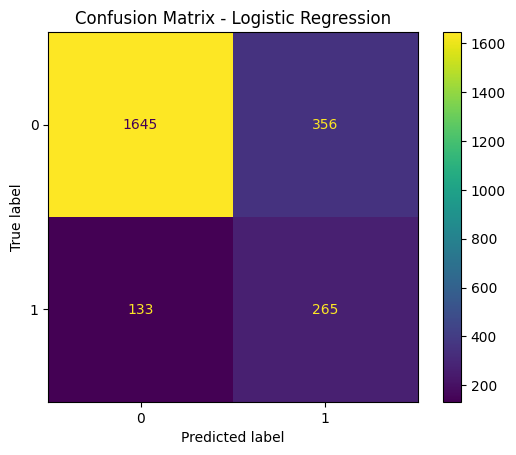

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_log = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm_log).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

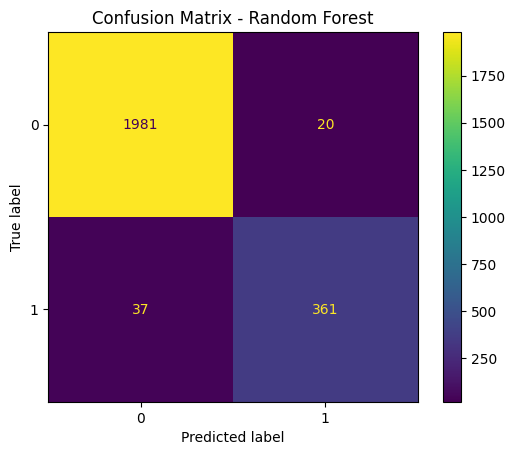

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

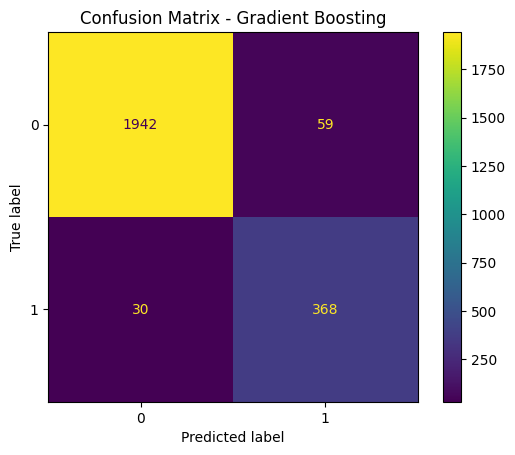

In [16]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

ConfusionMatrixDisplay(confusion_matrix=cm_gb).plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

Explain which metric needs to be used from the confusion matrix: Recall or Precision? 

I would say recall is more important for this project, sicne the company wants to identify as many employees likely to leave as possible so higher Recall means fewer employees who are actually likely to leave will be missed by the model.

Even though Precision is important I think Recall in this case is evne mor eimportant because its more important for us to correctly predict the employees whoa ctually leave

In [ ]:
# RETENTION STRATEGIES FOR TARGETED EMPLOYEES
turnover_probability = rf_model.predict_proba(X_test)[:,1] # Returns numpy array of probaiblties of people leaving
print(turnover_probability)

testData = X_test.copy() # .copy() creates a seperate DataFrame in memory

testData['TurnoverProb'] = turnover_probability
testData['TurnoverPercentage'] = turnover_probability * 100

def zoneAssigner(prob):
    if prob < .20:
        return "Safe Zone"
    elif .20 < prob < .60:
        return "Low-Risk"
    elif .60 < prob < .90:
        return "Medium Risk"
    elif prob > .90:
        return "Red, they're leaving"
    
testData['Zones'] = testData['TurnoverProb'].apply(zoneAssigner)
testData


[0.06 0.32 0.05 ... 0.   0.   0.06]


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,...,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,TurnoverProb,TurnoverPercentage,Zones
8578,0.82,0.95,6,191,6,0,0,False,True,False,...,False,False,False,False,False,False,True,0.06,6.0,Safe Zone
5756,0.18,0.86,5,267,4,0,0,False,True,False,...,False,False,False,False,False,False,True,0.32,32.0,Low-Risk
3994,0.63,0.98,4,160,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0.05,5.0,Safe Zone
1784,0.43,0.51,2,149,3,1,0,False,True,False,...,False,False,False,False,False,False,True,0.97,97.0,"Red, they're leaving"
10508,0.51,0.98,4,245,3,0,0,False,False,False,...,False,False,False,True,False,False,True,0.01,1.0,Safe Zone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2099,0.61,0.95,5,233,3,0,0,False,False,False,...,False,False,False,False,True,False,True,0.01,1.0,Safe Zone
5207,0.94,0.59,3,137,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0.00,0.0,Safe Zone
10865,0.96,0.68,3,132,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0.00,0.0,Safe Zone
5054,0.75,0.90,4,197,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0.00,0.0,Safe Zone


Safe Zone (Green) — Score < 20%
- Continue employee recognition and provide learning a growth oppurtunites and maintain a postive workplace culture

Low-Risk Zone (Yellow) — Score 20%–60%
- Regulary check up with them and ask for feedback as well as montior their workload and perhaps offer them more oppurtunities

Medium-Risk Zone (Orange) — Score 60%–90%
- Reduce their workload and increase their recognition and pay and be sure that you have constant communctions with them about whatever issues or struggles they may have

High-Risk Zone (Red) — Score > 90%
- Immediate one-on-one meetings with HR and managers, and offer salary raises or decrease workload, very important to communicate with these people as soon as possible